In [3]:
# importing libraries
import pandas as pd
import numpy as np

In [4]:
#Loading the dataset
df = pd.read_csv('../data/raw/combined_delay.csv')
schedule_df = pd.read_csv('../data/raw/combined_schedule.csv')
station_df = pd.read_csv('../data/raw/station_full_names.csv')
train_df = pd.read_csv('../data/raw/train_details.csv')

In [5]:
#to check wether data loaded properly or not
print("Delay Dataset Shape:", df.shape)

print("Schedule Dataset Shape:", schedule_df.shape)

print("Station Dataset Shape:", station_df.shape)

print("Train Dataset Shape:", train_df.shape)

Delay Dataset Shape: (38428703, 5)
Schedule Dataset Shape: (172112, 8)
Station Dataset Shape: (8963, 4)
Train Dataset Shape: (8992, 3)


In [6]:
#viewing data
df.head()
schedule_df.head()

,station_no,station_name,distance_from_origin,arrival_day,arrival_time,departure_day,departure_time,train_no
0,1,MJ,0,1,NaN,1,09:45,961
1,2,FLD,26,1,11:00,1,11:15,961
2,3,KBK,47,1,12:45,1,NaN,961
3,1,KBK,0,1,NaN,1,14:30,962
4,2,FLD,22,1,16:00,1,16:15,962


In [7]:
#checking column names
station_df.columns
train_df.columns

Index(['train_no', 'train_name', 'type_code'], dtype='str')

In [8]:
train_df.columns

Index(['train_no', 'train_name', 'type_code'], dtype='str')

In [9]:
## Understand the data structure
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 38428703 entries, 0 to 38428702
Data columns (total 5 columns):
 #   Column        Dtype  
---  ------        -----  
 0   date          str    
 1   station_no    int64  
 2   station_name  str    
 3   delay         float64
 4   train_no      int64  
dtypes: float64(1), int64(2), str(2)
memory usage: 1.4 GB


In [10]:
#checking missing values if any
df.isnull().sum()

date                  0
station_no            0
station_name          0
delay           1874271
train_no              0
dtype: int64

In [11]:
## Checking the dataset shape
df.shape
schedule_df.shape
station_df.shape
train_df.shape

(8992, 3)

In [12]:
#Viewing Sample data
df.head()
schedule_df.head()
station_df.head()
train_df.head()

,train_no,train_name,type_code
0,1211,BD NK SPL,PASS-TRAINS
1,1212,NK BD SPL,PASS-TRAINS
2,1461,SUR DD DMU SPL,PASS-TRAINS
3,1462,DD SUR DMU SPL,PASS-TRAINS
4,3020,AZ KNJ PASS SPL,PASS-TRAINS


In [13]:
#Missing val
df.isnull().sum()

date                  0
station_no            0
station_name          0
delay           1874271
train_no              0
dtype: int64

In [14]:
#checking unique values
df['train_no'].nunique() # train number


7033

In [15]:
df['station_name'].nunique() # station number

8227

In [16]:
##Creating fact table by merging delay and schedule dataset
fact_train_delay = df.copy()

In [17]:
dim_train = train_df.copy() # Dim Train table

In [18]:
dim_station = station_df.copy() # Dim Station table

In [19]:
dim_schedule = schedule_df.copy() # Dim Schedule table

In [20]:
## Checking relation ship
fact_train_delay.columns

Index(['date', 'station_no', 'station_name', 'delay', 'train_no'], dtype='str')

In [21]:
## Checking relation ship
dim_train.columns

Index(['train_no', 'train_name', 'type_code'], dtype='str')

In [22]:
## Checking relation ship
dim_station.columns

Index(['station_name', 'station_full_name', 'station_zone', 'station_address'], dtype='str')

In [23]:
## Checking relation ship
dim_schedule.columns

Index(['station_no', 'station_name', 'distance_from_origin', 'arrival_day',
       'arrival_time', 'departure_day', 'departure_time', 'train_no'],
      dtype='str')

In [24]:
fact_delay_analysis = df.merge(
    schedule_df,
    on=["train_no", "station_name"],
    how="left"
)

In [25]:
##### Data Cleaning statrs
fact_delay_analysis = df.copy()

In [26]:
# Removing duplicates
fact_delay_analysis.drop_duplicates(inplace=True)

In [27]:
# Rechecking missing values
fact_delay_analysis.isnull().sum()

date                  0
station_no            0
station_name          0
delay           1874271
train_no              0
dtype: int64

In [28]:
fact_delay_analysis['delay'].fillna(
    fact_delay_analysis['delay'].median(),
    inplace=True
)

C:\Users\Abhishek Kumar\AppData\Local\Temp\ipykernel_4128\668163612.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  fact_delay_analysis['delay'].fillna(


0           16.0
1           16.0
2            0.0
3            0.0
4            0.0
            ... 
38428698    -4.0
38428699     5.0
38428700    -3.0
38428701     1.0
38428702    19.0
Name: delay, Length: 38428703, dtype: float64

In [29]:
# Fixing Datatypes
fact_delay_analysis['date'] = pd.to_datetime(
    fact_delay_analysis['date'],
    errors='coerce'
)

In [30]:
fact_delay_analysis['delay'] = pd.to_numeric(
    fact_delay_analysis['delay'],
    errors='coerce'
)

In [31]:
## featuring data for analysis
# Delay category

def categorize_delay(x):
    if x <= 15:
        return "Minor"
    elif x <= 60:
        return "Moderate"
    else:
        return "Severe"

fact_delay_analysis['delay_category'] = fact_delay_analysis['delay'].apply(categorize_delay)

In [32]:
#Convert Date Column
fact_delay_analysis['date'] = pd.to_datetime(
    fact_delay_analysis['date'],
    errors='coerce'
)

In [33]:
#Ensure Delay is Numeric
fact_delay_analysis['delay'] = pd.to_numeric(
    fact_delay_analysis['delay'],
    errors='coerce'
)

In [34]:
# Create day name
fact_delay_analysis['day_name'] = fact_delay_analysis['date'].dt.day_name()

In [35]:
#create weekday/weekend
fact_delay_analysis['day_type'] = fact_delay_analysis['date'].dt.dayofweek.apply(
    lambda x: 'Weekend' if x >= 5 else 'Weekday'
)

In [36]:
#Create Month Column
fact_delay_analysis['month'] = fact_delay_analysis['date'].dt.month

In [37]:
#create  month name
fact_delay_analysis['month_name'] = fact_delay_analysis['date'].dt.month_name()

In [38]:
#Creating Quarter
fact_delay_analysis['quarter'] = fact_delay_analysis['date'].dt.quarter

In [39]:
#Creating season feature as well
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Summer'
    elif month in [6, 7, 8, 9]:
        return 'Monsoon'
    else:
        return 'Post-Monsoon'

fact_delay_analysis['season'] = fact_delay_analysis['month'].apply(get_season)

In [40]:
# Creating station congestion feature
station_load = fact_delay_analysis['station_no'].value_counts()

fact_delay_analysis['station_congestion'] = fact_delay_analysis['station_no'].map(
    station_load
)

In [41]:
# Create delay severity
fact_delay_analysis['delay_severity_score'] = (
    fact_delay_analysis['delay'] *
    fact_delay_analysis['station_congestion']
)

In [42]:
# create delay flag
fact_delay_analysis['is_delayed'] = fact_delay_analysis['delay'].apply(
    lambda x: 1 if x > 0 else 0
)

In [43]:
# create severe delay flag
fact_delay_analysis['is_severe_delay'] = fact_delay_analysis['delay'].apply(
    lambda x: 1 if x > 60 else 0
)

In [44]:
# checking final dataset
fact_delay_analysis.head()

,date,station_no,station_name,delay,train_no,delay_category,day_name,day_type,month,month_name,quarter,season,station_congestion,delay_severity_score,is_delayed,is_severe_delay
0,2025-02-08,1,MJ,NaN,961,Severe,Saturday,Weekend,2,February,1,Winter,1895758,NaN,0,0
1,2025-02-10,1,MJ,NaN,961,Severe,Monday,Weekday,2,February,1,Winter,1895758,NaN,0,0
2,2025-02-12,1,MJ,0.0,961,Minor,Wednesday,Weekday,2,February,1,Winter,1895758,0.0,0,0
3,2025-02-13,1,MJ,0.0,961,Minor,Thursday,Weekday,2,February,1,Winter,1895758,0.0,0,0
4,2025-02-22,1,MJ,0.0,961,Minor,Saturday,Weekend,2,February,1,Winter,1895758,0.0,0,0


In [45]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [46]:
###### EXPLORATORY DATA ANALYSIS (EDA) ##

# Import Viualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
# Check delay statistics
fact_delay_analysis['delay'].describe()

count    3.655443e+07
mean     3.693559e+01
std      2.751629e+02
min     -1.200000e+02
25%      4.000000e+00
50%      1.600000e+01
75%      4.100000e+01
max      5.255920e+05
Name: delay, dtype: float64

In [48]:
fact_delay_analysis['delay'].max()

np.float64(525592.0)

In [49]:
fact_delay_analysis['delay'].sort_values(ascending=False).head(20)

35375076    525592.0
30895989    525585.0
9014830     525582.0
29678373    525581.0
13973804    525569.0
15195547    525546.0
32792488    525545.0
28383033    525545.0
33126098    525525.0
934655        7018.0
935020        7015.0
935385        7011.0
935750        7009.0
31291633      6332.0
33938767      6294.0
33939080      6288.0
33939393      6282.0
33939706      6273.0
33939746      6257.0
942749        6211.0
Name: delay, dtype: float64

In [50]:
fact_delay_analysis = fact_delay_analysis[
    (fact_delay_analysis['delay'] >= 0) &
    (fact_delay_analysis['delay'] <= 1000)
]

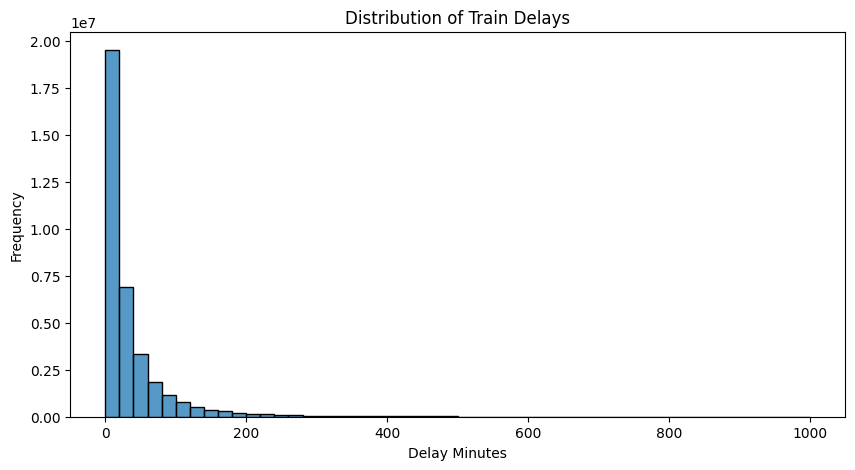

In [51]:
#Visualizing overall delays
plt.figure(figsize=(10,5))

sns.histplot(
    fact_delay_analysis['delay'],
    bins=50
)

plt.title('Distribution of Train Delays')

plt.xlabel('Delay Minutes')

plt.ylabel('Frequency')

plt.show()

Insights: - Extreme outlier delays exceeding operational feasibility were identified and removed to improve analytical accuracy and visualization clarity.

In [52]:
# top 10 most delay stations
top_stations = (
    fact_delay_analysis
    .groupby('station_name')['delay']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_stations

station_name
PGDP    509.000000
JRBI    256.322581
MOU     140.980584
CTHR    133.772956
DMF     133.433145
SWR     133.234437
KRMD    132.531313
GOL     131.537799
CKP     130.757953
TKYR    129.651439
Name: delay, dtype: float64

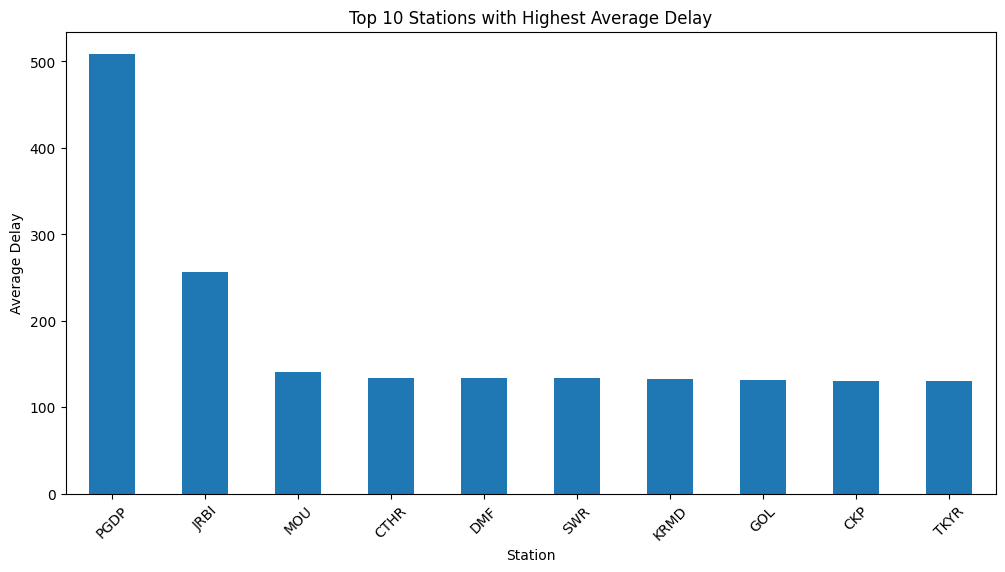

In [53]:
# Visualizing above top 10 most delay stations
plt.figure(figsize=(12,6))

top_stations.plot(kind='bar')

plt.title('Top 10 Stations with Highest Average Delay')

plt.xlabel('Station')

plt.ylabel('Average Delay')

plt.xticks(rotation=45)

plt.show()

In [54]:
#problematic train high
top_trains = (
    fact_delay_analysis
    .groupby('train_no')['delay']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_trains

train_no
7706     737.205128
4152     712.664671
7226     594.015038
7076     572.877287
20821    527.524520
12950    527.254028
1668     523.275449
8866     507.949580
3020     493.578947
20828    487.680077
Name: delay, dtype: float64

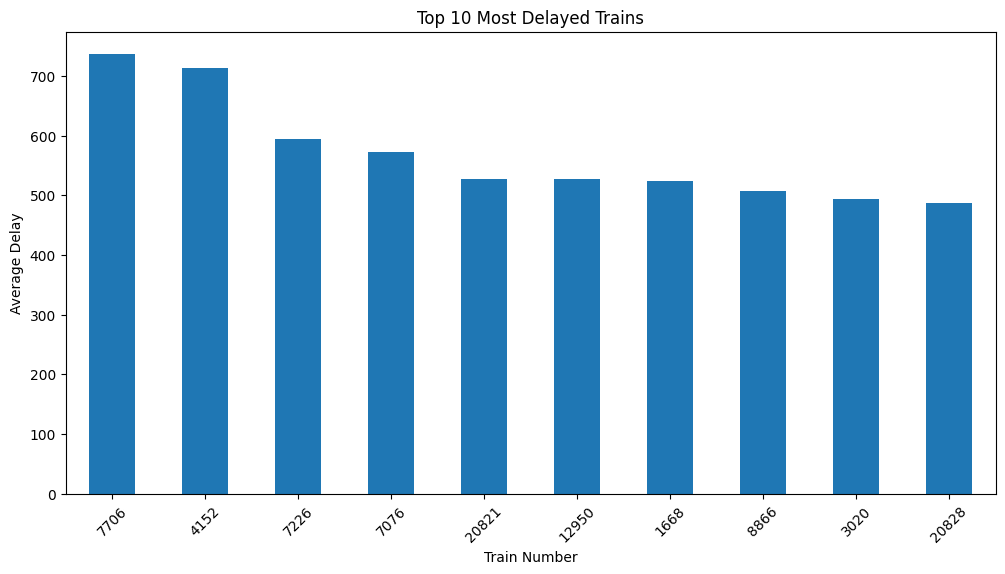

In [55]:
#Visualize above 

plt.figure(figsize=(12,6))

top_trains.plot(kind='bar')

plt.title('Top 10 Most Delayed Trains')

plt.xlabel('Train Number')

plt.ylabel('Average Delay')

plt.xticks(rotation=45)

plt.show()

In [56]:
#monthly delaytrend
monthly_delay = (
    fact_delay_analysis
    .groupby('month_name')['delay']
    .mean()
)

In [57]:
# sorting month order
month_order = [
    'January','February','March','April',
    'May','June','July','August',
    'September','October','November','December'
]

monthly_delay = monthly_delay.reindex(month_order)

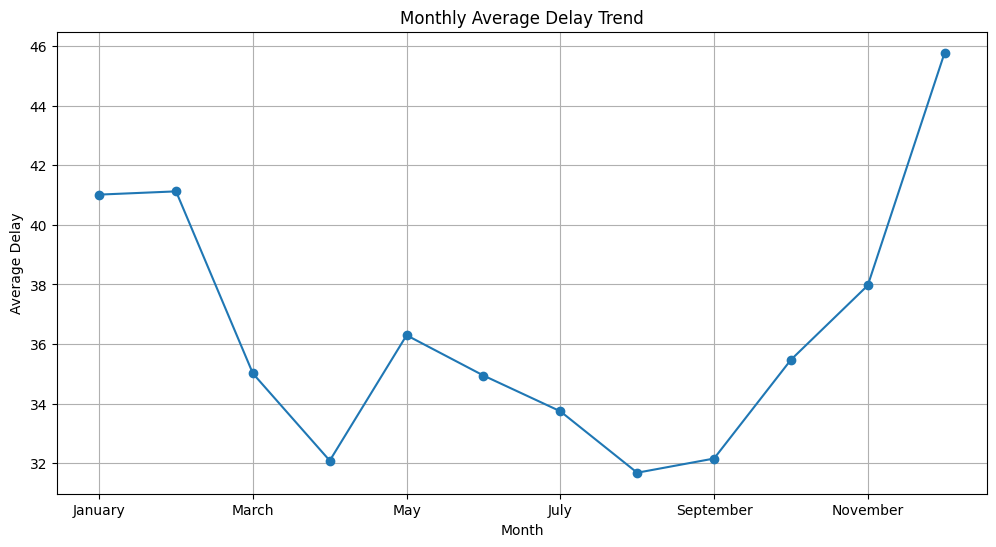

In [58]:
# visualize trend
plt.figure(figsize=(12,6))

monthly_delay.plot(marker='o')

plt.title('Monthly Average Delay Trend')

plt.xlabel('Month')

plt.ylabel('Average Delay')

plt.grid(True)

plt.show()

In [59]:
# season delay analysis
seasonal_delay = (
    fact_delay_analysis
    .groupby('season')['delay']
    .mean()
    .sort_values(ascending=False)
)

seasonal_delay

season
Winter          42.715196
Post-Monsoon    36.697881
Summer          34.489790
Monsoon         33.121158
Name: delay, dtype: float64

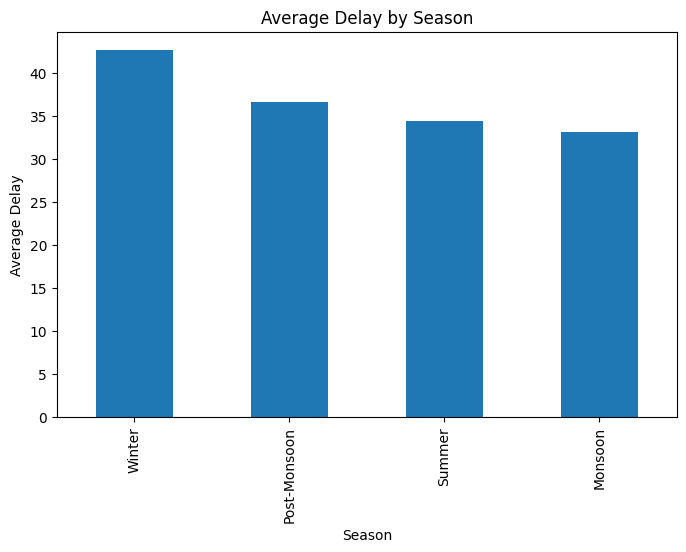

In [60]:
# visualize 
plt.figure(figsize=(8,5))

seasonal_delay.plot(kind='bar')

plt.title('Average Delay by Season')

plt.xlabel('Season')

plt.ylabel('Average Delay')

plt.show()


In [61]:
# Weekdays & weekend analysis
daytype_delay = (
    fact_delay_analysis
    .groupby('day_type')['delay']
    .mean()
)

daytype_delay

day_type
Weekday    36.426013
Weekend    36.299800
Name: delay, dtype: float64

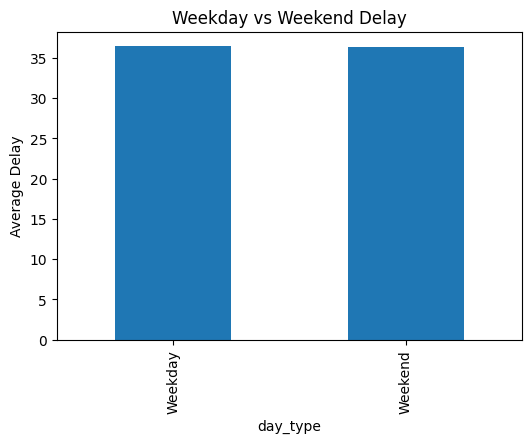

In [62]:
# visualize
plt.figure(figsize=(6,4))

daytype_delay.plot(kind='bar')

plt.title('Weekday vs Weekend Delay')

plt.ylabel('Average Delay')

plt.show()

In [63]:
# delay category distribution
fact_delay_analysis['delay_category'].value_counts()

delay_category
Minor       17337085
Moderate    12505210
Severe       5911241
Name: count, dtype: int64

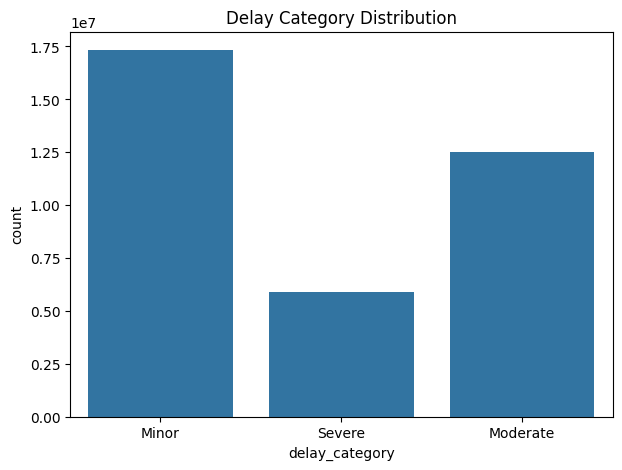

In [64]:
# visulaize
plt.figure(figsize=(7,5))

sns.countplot(
    x='delay_category',
    data=fact_delay_analysis
)

plt.title('Delay Category Distribution')

plt.show()

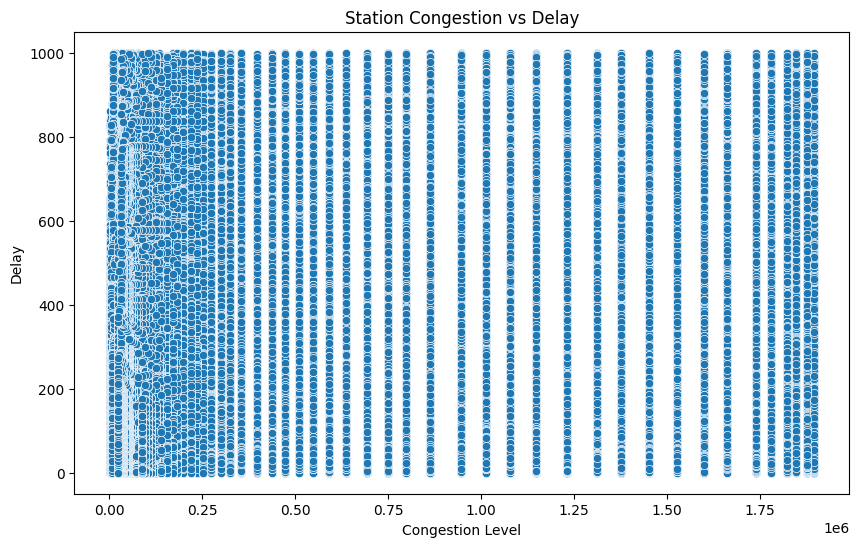

In [65]:
# congestion vs delay relationship
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='station_congestion',
    y='delay',
    data=fact_delay_analysis
)

plt.title('Station Congestion vs Delay')

plt.xlabel('Congestion Level')

plt.ylabel('Delay')

plt.show()

Insights: Weekday and weekend train delays show minimal variation, indicating that railway delays are influenced more by operational and infrastructure factors than passenger demand fluctuations across the week.

In [66]:

fact_delay_analysis['severe_delay'] = fact_delay_analysis['delay'].apply(
    lambda x: 1 if x > 60 else 0
)

In [67]:
##### Root cause Analysis###

# Sever delay analysis
severe_station = (
    fact_delay_analysis
    .groupby('station_name')['severe_delay']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

severe_station

station_name
CNB     16339
RJY     15463
KGP     13783
KUR     13572
SLO     13318
BBS     13087
GKP     13031
ROU     12923
TATA    12323
SPJ     12042
Name: severe_delay, dtype: int64

In [68]:
fact_delay_analysis[['delay', 'severe_delay']].head()

,delay,severe_delay
2,0.0,0
3,0.0,0
4,0.0,0
5,0.0,0
6,0.0,0


In [69]:
# congestion impact analysis
fact_delay_analysis[
    ['delay', 'station_congestion']
].corr()

,delay,station_congestion
delay,1.000000,-0.230852
station_congestion,-0.230852,1.000000


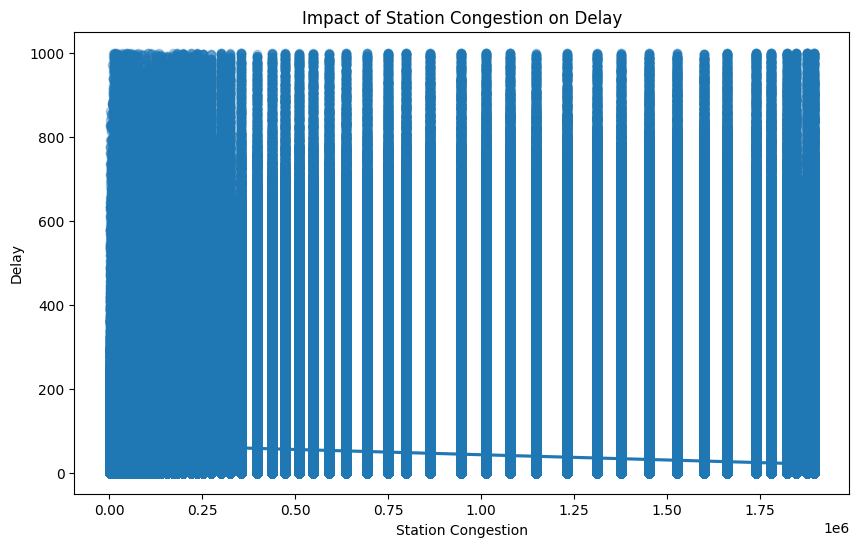

In [70]:
# visualize above

plt.figure(figsize=(10,6))

sns.regplot(
    x='station_congestion',
    y='delay',
    data=fact_delay_analysis,
    scatter_kws={'alpha':0.3}
)

plt.title('Impact of Station Congestion on Delay')

plt.xlabel('Station Congestion')

plt.ylabel('Delay')

plt.show()

In [71]:
# season RCA
seasonal_rootcause = (
    fact_delay_analysis
    .groupby('season')['delay']
    .agg(['mean','max','count'])
)

seasonal_rootcause

,mean,max,count
season,,,
Monsoon,33.121158,1000.0,12086904
Post-Monsoon,36.697881,1000.0,6097313
Summer,34.489790,1000.0,8934151
Winter,42.715196,1000.0,8635168


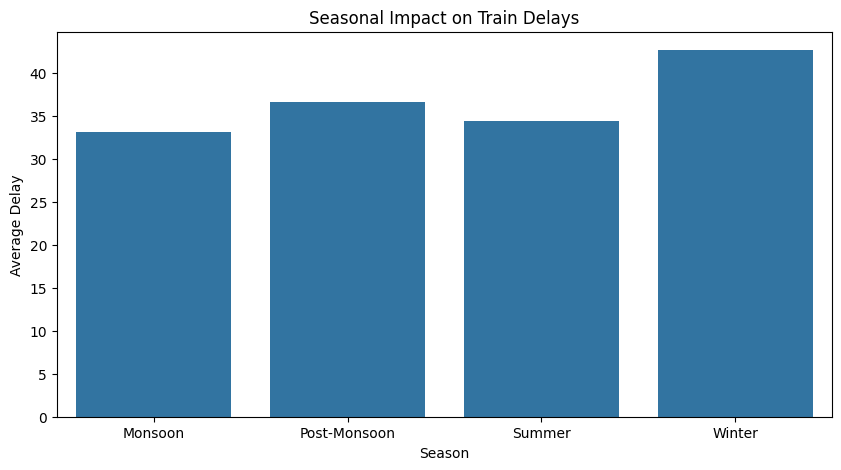

In [72]:
# Visualize
plt.figure(figsize=(10,5))

sns.barplot(
    x=seasonal_rootcause.index,
    y=seasonal_rootcause['mean']
)

plt.title('Seasonal Impact on Train Delays')

plt.xlabel('Season')

plt.ylabel('Average Delay')

plt.show()

In [73]:
### Delay Concentration analysis
# top station contribution
station_delay_total = (
    fact_delay_analysis
    .groupby('station_name')['delay']
    .sum()
    .sort_values(ascending=False)
)

station_delay_total.head(10)

station_name
CNB     3776448.0
KGP     3308022.0
BSL     3011283.0
NDLS    2831707.0
GKP     2826202.0
TATA    2809107.0
BZA     2787572.0
KUR     2729640.0
BBS     2658419.0
RJY     2648402.0
Name: delay, dtype: float64

Insight: 10–20 stations contribute majority of delays

In [74]:
# Train reliability Analysis
train_reliability = (
    fact_delay_analysis
    .groupby('train_no')['delay']
    .agg(['mean','max','count'])
    .sort_values(by='mean', ascending=False)
)

train_reliability.head(10)

,mean,max,count
train_no,,,
7706,737.205128,994.0,39
4152,712.664671,995.0,334
7226,594.015038,1000.0,399
7076,572.877287,999.0,929
20821,527.524520,999.0,469
12950,527.254028,1000.0,1862
1668,523.275449,998.0,334
8866,507.949580,886.0,119
3020,493.578947,592.0,19


In [75]:
# delay severity distribution
severity_dist = (
    fact_delay_analysis['delay_category']
    .value_counts(normalize=True) * 100
)

severity_dist

delay_category
Minor       48.490547
Moderate    34.976149
Severe      16.533305
Name: proportion, dtype: float64

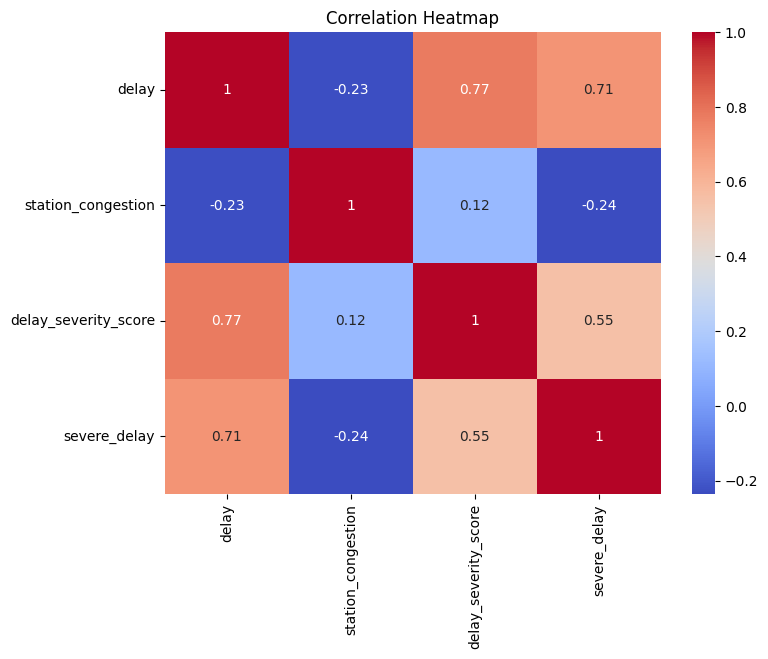

In [76]:
# coorelation analysis
plt.figure(figsize=(8,6))

sns.heatmap(
    fact_delay_analysis[
        ['delay',
         'station_congestion',
         'delay_severity_score',
         'severe_delay']
    ].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

In [77]:
fact_delay_analysis.to_csv(
    '../data/cleaned/fact_delay_analysis_cleaned.csv',
    index=False
)

In [78]:
fact_delay_analysis.shape

(35753536, 17)

In [82]:
fact_delay_analysis_sample = fact_delay_analysis.sample(
    n=250000,
    random_state=42
)

In [80]:
fact_delay_analysis_sample.shape

(250000, 17)

In [81]:
fact_delay_analysis_sample.to_csv(
    '../data/cleaned/fact_delay_analysis_clean.csv',
    index=False
)

In [91]:
fact_delay_analysis_sample['station_congestion'] = (
    fact_delay_analysis_sample
    .groupby('station_name')['train_no']
    .transform('count')
)

In [92]:
fact_delay_analysis_sample[
    fact_delay_analysis_sample['station_name'] == 'NDLS'
][['station_name', 'station_congestion']].head()

,station_name,station_congestion
1188125,NDLS,509
5333677,NDLS,509
18658809,NDLS,509
8714881,NDLS,509
2866480,NDLS,509


In [93]:
fact_delay_analysis_sample.to_csv(
    '../data/cleaned/fact_delay_analysis_sample.csv',
    index=False
)

In [95]:
top_delayed_stations = (
    fact_delay_analysis_sample
    .groupby('station_name')['delay']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_delayed_stations

station_name
KMQA    185.000000
GRRG    175.076923
MJRI    172.333333
KTHA    170.833333
ADL     163.250000
JKB     159.833333
MNDK    157.000000
SRL     156.500000
PBV     156.333333
UB      155.314286
Name: delay, dtype: float64

In [96]:
fact_delay_analysis_sample.groupby('station_name')['delay'] \
.mean() \
.sort_values(ascending=False) \
.head(10)

station_name
KMQA    185.000000
GRRG    175.076923
MJRI    172.333333
KTHA    170.833333
ADL     163.250000
JKB     159.833333
MNDK    157.000000
SRL     156.500000
PBV     156.333333
UB      155.314286
Name: delay, dtype: float64

In [97]:
fact_delay_analysis_sample.groupby('station_name')['severe_delay'] \
.sum() \
.sort_values(ascending=False) \
.head(10)

station_name
SLO     112
RJY     107
KUR     105
CNB     103
TATA     99
G        94
ROU      94
BBS      93
CTC      92
DLI      90
Name: severe_delay, dtype: int64

In [100]:
hi=(fact_delay_analysis_sample
    .groupby('station_name')['severe_delay']
    .sum()
    .sort_values(ascending=False)
    .head(10))
hi

station_name
SLO     112
RJY     107
KUR     105
CNB     103
TATA     99
G        94
ROU      94
BBS      93
CTC      92
DLI      90
Name: severe_delay, dtype: int64

In [104]:
top_delayed_trains = (
    fact_delay_analysis_sample
    .groupby('train_no')['delay']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_delayed_trains

train_no
5311     989.000000
2188     954.000000
20416    789.000000
4152     744.333333
2186     715.000000
4654     669.000000
7226     657.250000
1668     623.000000
7076     560.666667
8866     558.500000
Name: delay, dtype: float64

In [105]:
top_severe_trains = (
    fact_delay_analysis_sample
    .groupby('train_no')['severe_delay']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_severe_trains

train_no
18030    148
18477    142
12834    139
19038    127
63557    121
11273    121
19014    112
11274    111
13351    109
18478    109
Name: severe_delay, dtype: int64

In [109]:
# to find the min delay 
fact_delay_analysis_sample['delay'].min()

np.float64(0.0)

In [110]:
# to find the max delay
fact_delay_analysis_sample['delay'].max()

np.float64(992.0)

In [111]:
#to find the average delay
fact_delay_analysis_sample['delay'].mean()

np.float64(36.456444)

In [113]:
# train number having the highest avg operational delays
top_severe_trains.index[0]

np.int64(18030)

In [114]:
fact_delay_analysis_sample.groupby('day_type')['delay'] \
.mean()

day_type
Weekday    36.338215
Weekend    36.755932
Name: delay, dtype: float64

In [115]:
fact_delay_analysis_sample['train_no'].count()

np.int64(250000)